# NBA Players stats(2023 season)
### 2022-2023的 82 場例行賽
[點我看網站](https://www.kaggle.com/datasets/amirhosseinmirzaie/nba-players-stats2023-season)

## Position與進攻、防守的關係
- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import random

In [2]:
np.random.seed(42)

In [3]:
data = pd.read_csv('2023nbasalary.csv')

In [4]:
data.head()

,PName,POS,Team,Age,GP,W,L,Min,PTS,FGM,...,APG,TOPG,SPG,BPG,FPG,TS%,AT,Avg_PM,Avg_FP,Salary
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,4.621622,2.878378,1.054054,0.689189,2.162162,60.703451,1.605634,6.351351,49.878378,32600060.0
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,4.151515,3.424242,1.000000,1.696970,3.106061,65.467479,1.212389,6.424242,56.151515,53320232.0
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,8.015152,3.575758,1.363636,0.500000,2.515152,60.933902,2.241525,1.939394,56.772727,43031940.0
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,5.455882,2.823529,1.647059,0.955882,2.823529,62.567403,1.932292,2.191176,50.367647,35859950.0
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,5.698413,3.904762,0.825397,0.809524,3.126984,60.549676,1.459350,5.412698,54.777778,45640084.0


| G | SG | PG | F | SF | PF | C |
|----|---|----|----|----|---|---|
| Guard | Shooting_Guard | Point_Guard | Forward | Small_Forward | Power_Forward | Center |
| 後衛 | 得分後衛 | 控球後衛 | 前鋒 | 小前鋒 | 大前鋒 | 中鋒 |

In [5]:
data.rename(columns={
    'PName': 'Player_Name',
    'POS': 'Position',
    'Team': 'Team_Abbreviation',
    'Age': 'Age',
    'GP': 'Games_Played',
    'W': 'Wins',
    'L': 'Losses',
    'Min': 'Minutes_Played',
    'PTS': 'Total_Points',
    'FGM': 'Field_Goal_Made',
    'FGA': 'Field_Goal_Attempted',
    'FG%': 'Field_Goal_Percentage',
    '3PM': 'Three_Point_Made',
    '3PA': 'Three_Point_Attempted',
    '3P%': 'Three_Point_Percentage',
    'FTM': 'Free_Throw_Made',
    'FTA': 'Free_Throw_Attempted',
    'FT%': 'Free_Throw_Percentage',
    'OREB': 'Offensive_Rebounds',
    'DREB': 'Defensive_Rebounds',
    'REB': 'Total_Rebounds',
    'AST': 'Assists',
    'TOV': 'Turnovers',
    'STL': 'Steals',
    'BLK': 'Blocks',
    'PF': 'Personal_Fouls',
    'FP': 'NBA_Fantasy_Points',
    'DD2': 'Double_Doubles',
    'TD3': 'Triple_Doubles',
    '+/-': 'Plus_Minus',
    'PPG': 'Points_Per_Game',
    'RPG': 'Rebounds_Per_Game',
    'APG' :'Assists_Per_Game',
    'TOPG' :'Turnovers_Per_Game',
    'SPG' :'Steals_Per_Game',
    'BPG' :'Blocks_Per_Game',
    'FPG' :'Fouls_Per_Game',
    'TS%' :'True_Shooting_Percentage'
}, inplace=True)

## 欄位說明
[參考](https://www.basketball-reference.com/about/glossary.html#fg)

| 原始欄位 | 英文說明欄位 | 中文解釋 |
|---------|--------------|----------|
| PName   | Player_Name | 球員姓名 |
| POS     | Position | 場上位置 |
| Team    | Team_Abbreviation | 球隊縮寫 |
| Age     | Age | 年齡 |
| GP      | Games_Played | 出賽場次 |
| W       | Wins | 勝場 |
| L       | Losses | 敗場 |
| Min     | Minutes_Played | 上場時間（分鐘） |
| PTS     | Total_Points | 總得分 |
| FGM     | Field_Goal_Made | 投籃命中數 |
| FGA     | Field_Goal_Attempted | 投籃出手數 |
| FG%     | Field_Goal_Percentage | 投籃命中率 |
| 3PM     | Three_Point_Made | 三分命中數 |
| 3PA     | Three_Point_Attempted | 三分出手數 |
| 3P%     | Three_Point_Percentage | 三分命中率 |
| FTM     | Free_Throw_Made | 罰球命中數 |
| FTA     | Free_Throw_Attempted | 罰球出手數 |
| FT%     | Free_Throw_Percentage | 罰球命中率 |
| OREB    | Offensive_Rebounds | 進攻籃板 |
| DREB    | Defensive_Rebounds | 防守籃板 |
| REB     | Total_Rebounds | 總籃板 |
| AST     | Assists | 助攻 |
| TOV     | Turnovers | 失誤 |
| STL     | Steals | 抄截 |
| BLK     | Blocks | 阻攻（火鍋） |
| PF      | Personal_Fouls | 犯規 |
| FP      | NBA_Fantasy_Points | NBA Fantasy 積分 |
| DD2     | Double_Doubles | 「雙十」次數 |
| TD3     | Triple_Doubles | 「大三元」次數 |
| +/-     | Plus_Minus | 場上正負值 |
| PPG     | Points Per Game | 場均得分 |
| RPG     | Rebounds Per Game | 場均籃板 |
| APG     | Assists Per Game | 場均助攻 |
| TOPG    | Turnovers Per Game | 場均失誤 |
| SPG     | Steals Per Game | 場均抄截 |
| BPG     | Blocks Per Game | 場均蓋冒 | 
| FPG     | Fouls Per Game | 場均犯規 |
| TS%     | True Shooting Percentage | 真實命中率 | 

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player_Name               539 non-null    object 
 1   Position                  539 non-null    object 
 2   Team_Abbreviation         539 non-null    object 
 3   Age                       539 non-null    int64  
 4   Games_Played              539 non-null    int64  
 5   Wins                      539 non-null    int64  
 6   Losses                    539 non-null    int64  
 7   Minutes_Played            539 non-null    float64
 8   Total_Points              539 non-null    int64  
 9   Field_Goal_Made           539 non-null    int64  
 10  Field_Goal_Attempted      539 non-null    int64  
 11  Field_Goal_Percentage     539 non-null    float64
 12  Three_Point_Made          539 non-null    int64  
 13  Three_Point_Attempted     539 non-null    int64  
 14  Three_Poin

In [7]:
data['Salary'] = data['Salary'].fillna((data['Salary']).median())

In [8]:
data.duplicated().sum()

0

In [9]:
data.isna().sum()

Player_Name                  0
Position                     0
Team_Abbreviation            0
Age                          0
Games_Played                 0
Wins                         0
Losses                       0
Minutes_Played               0
Total_Points                 0
Field_Goal_Made              0
Field_Goal_Attempted         0
Field_Goal_Percentage        0
Three_Point_Made             0
Three_Point_Attempted        0
Three_Point_Percentage       0
Free_Throw_Made              0
Free_Throw_Attempted         0
Free_Throw_Percentage        0
Offensive_Rebounds           0
Defensive_Rebounds           0
Total_Rebounds               0
Assists                      0
Turnovers                    0
Steals                       0
Blocks                       0
Personal_Fouls               0
NBA_Fantasy_Points           0
Double_Doubles               0
Triple_Doubles               0
Plus/Minus                   0
Points_Per_Game              0
Rebounds_Per_Game            0
Assists_

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Player_Name</th>
      <th>Position</th>
      <th>Team_Abbreviation</th>
      <th>Age</th>
      <th>Games_Played</th>
      <th>Wins</th>
      <th>Losses</th>
      <th>Minutes_Played</th>
      <th>Total_Points</th>
      <th>Field_Goal_Made</th>
      <th>...</th>
      <th>Three_Point_Made_Per_Game</th>
      <th>Three_Point_Attempted_Per_Game</th>
      <th>Three_Point_Attempted_Rate</th>
      <th>Free_Throw_Attempted_Per_Game</th>
      <th>Minutes_Played_Per_Game</th>
      <th>Assists/Turnover_Percentage</th>
      <th>Usage_Percentage</th>
      <th>Effective_Field_Goal_Percentage</th>
      <th>Assists_Percentage</th>
      <th>Turnovers_Percentage</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Jayson Tatum</td>
      <td>SF</td>
      <td>BOS</td>
      <td>25</td>
      <td>74</td>
      <td>52</td>
      <td>22</td>
      <td>2732.2</td>
      <td>2225</td>
      <td>727</td>
      <td>...</td>
      <td>3.243243</td>
      <td>9.270270</td>
      <td>44.002566</td>
      <td>8.405405</td>
      <td>36.921622</td>
      <td>160.563380</td>
      <td>33.060489</td>
      <td>54.329699</td>
      <td>21.019590</td>
      <td>10.412186</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Joel Embiid</td>
      <td>C</td>
      <td>PHI</td>
      <td>29</td>
      <td>66</td>
      <td>43</td>
      <td>23</td>
      <td>2284.1</td>
      <td>2183</td>
      <td>728</td>
      <td>...</td>
      <td>1.000000</td>
      <td>3.030303</td>
      <td>15.060241</td>
      <td>11.681818</td>
      <td>34.607576</td>
      <td>121.238938</td>
      <td>36.939470</td>
      <td>57.304217</td>
      <td>22.687995</td>
      <td>11.937208</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Luka Doncic</td>
      <td>PG</td>
      <td>DAL</td>
      <td>24</td>
      <td>66</td>
      <td>33</td>
      <td>33</td>
      <td>2390.5</td>
      <td>2138</td>
      <td>719</td>
      <td>...</td>
      <td>2.803030</td>
      <td>8.196970</td>
      <td>37.336094</td>
      <td>10.515152</td>
      <td>36.219697</td>
      <td>224.152542</td>
      <td>36.139285</td>
      <td>56.004141</td>
      <td>38.693547</td>
      <td>11.857151</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Shai Gilgeous-Alexander</td>
      <td>PG</td>
      <td>OKC</td>
      <td>24</td>
      <td>68</td>
      <td>33</td>
      <td>35</td>
      <td>2416.0</td>
      <td>2135</td>
      <td>704</td>
      <td>...</td>
      <td>0.852941</td>
      <td>2.470588</td>
      <td>12.165098</td>
      <td>10.867647</td>
      <td>35.529412</td>
      <td>193.229167</td>
      <td>32.573588</td>
      <td>53.077480</td>
      <td>25.273725</td>
      <td>10.115059</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Giannis Antetokounmpo</td>
      <td>PF</td>
      <td>MIL</td>
      <td>28</td>
      <td>63</td>
      <td>47</td>
      <td>16</td>
      <td>2023.6</td>
      <td>1959</td>
      <td>707</td>
      <td>...</td>
      <td>0.746032</td>
      <td>2.714286</td>
      <td>13.380282</td>
      <td>12.253968</td>
      <td>32.120635</td>
      <td>145.934959</td>
      <td>38.208234</td>
      <td>57.159624</td>
      <td>31.730435</td>
      <td>13.199691</td>
    </tr>
  </tbody>
</table>
<p>5 rows × 65 columns</p>
</div>

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Player_Name</th>
      <th>Position</th>
      <th>Team_Abbreviation</th>
      <th>Age</th>
      <th>Games_Played</th>
      <th>Wins</th>
      <th>Losses</th>
      <th>Minutes_Played</th>
      <th>Total_Points</th>
      <th>Field_Goal_Made</th>
      <th>...</th>
      <th>Three_Point_Made_Per_Game</th>
      <th>Three_Point_Attempted_Per_Game</th>
      <th>Three_Point_Attempted_Rate</th>
      <th>Free_Throw_Attempted_Per_Game</th>
      <th>Minutes_Played_Per_Game</th>
      <th>Assists/Turnover_Percentage</th>
      <th>Usage_Percentage</th>
      <th>Effective_Field_Goal_Percentage</th>
      <th>Assists_Percentage</th>
      <th>Turnovers_Percentage</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Jayson Tatum</td>
      <td>SF</td>
      <td>BOS</td>
      <td>25</td>
      <td>74</td>
      <td>52</td>
      <td>22</td>
      <td>2732.2</td>
      <td>2225</td>
      <td>727</td>
      <td>...</td>
      <td>3.243243</td>
      <td>9.270270</td>
      <td>44.002566</td>
      <td>8.405405</td>
      <td>36.921622</td>
      <td>160.563380</td>
      <td>33.060489</td>
      <td>54.329699</td>
      <td>21.019590</td>
      <td>10.412186</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Joel Embiid</td>
      <td>C</td>
      <td>PHI</td>
      <td>29</td>
      <td>66</td>
      <td>43</td>
      <td>23</td>
      <td>2284.1</td>
      <td>2183</td>
      <td>728</td>
      <td>...</td>
      <td>1.000000</td>
      <td>3.030303</td>
      <td>15.060241</td>
      <td>11.681818</td>
      <td>34.607576</td>
      <td>121.238938</td>
      <td>36.939470</td>
      <td>57.304217</td>
      <td>22.687995</td>
      <td>11.937208</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Luka Doncic</td>
      <td>PG</td>
      <td>DAL</td>
      <td>24</td>
      <td>66</td>
      <td>33</td>
      <td>33</td>
      <td>2390.5</td>
      <td>2138</td>
      <td>719</td>
      <td>...</td>
      <td>2.803030</td>
      <td>8.196970</td>
      <td>37.336094</td>
      <td>10.515152</td>
      <td>36.219697</td>
      <td>224.152542</td>
      <td>36.139285</td>
      <td>56.004141</td>
      <td>38.693547</td>
      <td>11.857151</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Shai Gilgeous-Alexander</td>
      <td>PG</td>
      <td>OKC</td>
      <td>24</td>
      <td>68</td>
      <td>33</td>
      <td>35</td>
      <td>2416.0</td>
      <td>2135</td>
      <td>704</td>
      <td>...</td>
      <td>0.852941</td>
      <td>2.470588</td>
      <td>12.165098</td>
      <td>10.867647</td>
      <td>35.529412</td>
      <td>193.229167</td>
      <td>32.573588</td>
      <td>53.077480</td>
      <td>25.273725</td>
      <td>10.115059</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Giannis Antetokounmpo</td>
      <td>PF</td>
      <td>MIL</td>
      <td>28</td>
      <td>63</td>
      <td>47</td>
      <td>16</td>
      <td>2023.6</td>
      <td>1959</td>
      <td>707</td>
      <td>...</td>
      <td>0.746032</td>
      <td>2.714286</td>
      <td>13.380282</td>
      <td>12.253968</td>
      <td>32.120635</td>
      <td>145.934959</td>
      <td>38.208234</td>
      <td>57.159624</td>
      <td>31.730435</td>
      <td>13.199691</td>
    </tr>
  </tbody>
</table>
<p>5 rows × 65 columns</p>
</div>

In [10]:
data.head()

,Player_Name,Position,Team_Abbreviation,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,...,Assists_Per_Game,Turnovers_Per_Game,Steals_Per_Game,Blocks_Per_Game,Fouls_Per_Game,True_Shooting_Percentage,AT,Avg_PM,Avg_FP,Salary
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,4.621622,2.878378,1.054054,0.689189,2.162162,60.703451,1.605634,6.351351,49.878378,32600060.0
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,4.151515,3.424242,1.000000,1.696970,3.106061,65.467479,1.212389,6.424242,56.151515,53320232.0
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,8.015152,3.575758,1.363636,0.500000,2.515152,60.933902,2.241525,1.939394,56.772727,43031940.0
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,5.455882,2.823529,1.647059,0.955882,2.823529,62.567403,1.932292,2.191176,50.367647,35859950.0
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,5.698413,3.904762,0.825397,0.809524,3.126984,60.549676,1.459350,5.412698,54.777778,45640084.0


### FieldGoalPerGame

In [11]:
data['Field_Goal_Attempted_Per_Game'] = data['Field_Goal_Attempted']/data['Games_Played'].where(data['Games_Played']>0, 0)

data['Field_Goal_Made_Per_Game'] = data['Field_Goal_Made']/data['Games_Played'].where(data['Games_Played']>0, 0)

### ReboundsPerGame

In [12]:
data['Offensive_Rebounds_Per_Game'] = (data['Offensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)
data['Defensive_Rebounds_Per_Game'] = (data['Defensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)

### TeamData

In [13]:
team_data = (data.groupby("Team_Abbreviation").agg(Team_FGA=("Field_Goal_Attempted", "sum"), Team_FTA=("Free_Throw_Attempted", "sum"), 
                                                  Team_TOV=("Turnovers", "sum"), Team_MP =("Minutes_Played", "sum"), Team_FGM=('Field_Goal_Made', 'sum')))
data = data.merge(team_data, on="Team_Abbreviation", how="left")

### TwoPoints

In [14]:
data["Two_Point_Made"] = data["Field_Goal_Made"]-data["Three_Point_Made"]
data['Two_Point_Made_Per_Game'] = data["Two_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data["Two_Point_Attempted"] = data["Field_Goal_Attempted"]-data["Three_Point_Attempted"]
data['Two_Point_Attempted_Per_Game'] = data["Two_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)
data['Two_Point_Attempted_Rate'] = (100*data["Two_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)

data["Two_Point_Percentage"] = (100*data["Two_Point_Made"]/data["Two_Point_Attempted"]).where(data["Two_Point_Attempted"]>0, 0)

### ThreePoints

In [15]:
data['Three_Point_Made_Per_Game'] = data["Three_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Per_Game'] = data["Three_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Rate'] = (100*data["Three_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)


### FreeThrowPerGame

In [16]:
data['Free_Throw_Attempted_Per_Game'] = data["Free_Throw_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

### MinutesPlayedPerGame

In [17]:
data['Minutes_Played_Per_Game'] = data['Minutes_Played'] / data['Games_Played'].where(data["Games_Played"]>0, 0)

### BlocksPerGame

In [18]:
data["Blocks_Per_Game"] = data["Blocks"] / data["Games_Played"]

### TS%

In [19]:
data['True_Shooting_Percentage'] = pd.to_numeric(data['True_Shooting_Percentage'], errors='coerce')
data['True_Shooting_Percentage'] = data['True_Shooting_Percentage'].fillna(0)

### Usage%

In [20]:
son =  ((data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers'])*(data['Team_MP']/5))
mom = data["Minutes_Played"]*(data["Team_FGA"]+0.44*data["Team_FTA"]+data["Team_TOV"])
data['Usage_Percentage'] = (100*son/mom).where(mom>0, 0)

### eFG%

In [21]:
data['Effective_Field_Goal_Percentage'] = (100*((data['Field_Goal_Made']+0.5*data['Three_Point_Made'])/data['Field_Goal_Attempted'])).where(data["Field_Goal_Attempted"]>0, 0)

### AST%

In [22]:
mom2 = (((data['Minutes_Played']/(data['Team_MP']/5))*data['Team_FGM']))-data['Field_Goal_Made']
data['Assists_Percentage'] = (100*data['Assists']/mom2).where(mom2>0, 0)

### TOV%

In [23]:
mom3 = data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers']
data['Turnovers_Percentage'] = (100*data['Turnovers'])/mom3.where(mom3>0, 0)

---

In [24]:
data.describe()

,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,Field_Goal_Attempted,Field_Goal_Percentage,Three_Point_Made,...,Two_Point_Percentage,Three_Point_Made_Per_Game,Three_Point_Attempted_Per_Game,Three_Point_Attempted_Rate,Free_Throw_Attempted_Per_Game,Minutes_Played_Per_Game,Usage_Percentage,Effective_Field_Goal_Percentage,Assists_Percentage,Turnovers_Percentage
count,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,...,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,538.000000
mean,25.970315,48.040816,24.018553,24.022263,1103.617625,523.426716,191.576994,403.005566,46.325232,56.324675,...,52.988137,0.990038,2.782890,40.029688,1.855938,19.796567,18.574018,53.187150,13.467328,12.593740
std,4.315513,24.650686,14.496366,13.445866,827.765114,498.084360,178.351286,369.595909,10.967271,60.916821,...,14.029320,0.872909,2.243816,21.981050,1.880296,9.541295,5.825914,10.618800,8.671406,6.922353
min,19.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,30.500000,12.000000,14.000000,329.000000,120.500000,45.500000,93.500000,41.650000,5.000000,...,48.532999,0.316986,1.000000,25.993266,0.629123,12.452484,14.394007,49.441898,7.274880,9.448659
50%,25.000000,54.000000,25.000000,25.000000,970.200000,374.000000,138.000000,300.000000,45.500000,36.000000,...,53.592814,0.789474,2.365385,40.838852,1.225000,19.185185,17.847983,53.773585,11.082953,11.852746
75%,29.000000,68.000000,36.000000,34.000000,1845.900000,769.500000,283.500000,598.500000,50.600000,92.000000,...,59.406736,1.489512,4.097619,54.694057,2.407077,28.346682,21.428119,57.619444,17.679265,15.025182
max,42.000000,83.000000,57.000000,60.000000,2963.200000,2225.000000,728.000000,1559.000000,100.000000,301.000000,...,100.000000,4.875000,11.410714,100.000000,12.253968,40.800000,49.082544,100.000000,48.812111,100.000000


C:\Users\No\AppData\Local\Temp\ipykernel_19364\1457757444.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(data['Minutes_Played_Per_Game'], labels=[''])


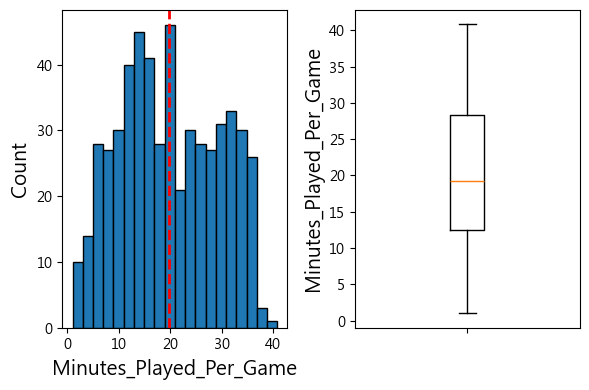

In [25]:
mean_MPg = data['Minutes_Played_Per_Game'].mean()

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax = ax.flatten()
ax[0].hist(data['Minutes_Played_Per_Game'], bins=20, edgecolor='k')
ax[0].set_xlabel('Minutes_Played_Per_Game', fontsize=14)
ax[0].set_ylabel('Count', fontsize=14)
ax[0].axvline(mean_MPg, color='red', linestyle='--', linewidth=2)

ax[1].boxplot(data['Minutes_Played_Per_Game'], labels=[''])
ax[1].set_ylabel('Minutes_Played_Per_Game', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\No\AppData\Local\Temp\ipykernel_19364\3243140165.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(data['Games_Played'], labels=[''])


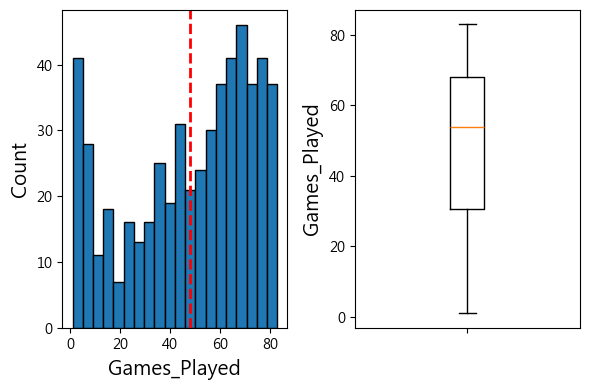

In [26]:
mean_MPg = data['Games_Played'].mean()

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax = ax.flatten()
ax[0].hist(data['Games_Played'], bins=20, edgecolor='k')
ax[0].set_xlabel('Games_Played', fontsize=14)
ax[0].set_ylabel('Count', fontsize=14)
ax[0].axvline(mean_MPg, color='red', linestyle='--', linewidth=2)

ax[1].boxplot(data['Games_Played'], labels=[''])
ax[1].set_ylabel('Games_Played', fontsize=14)

plt.tight_layout()
plt.show()

In [27]:
GP_mean = data['Games_Played'].mean()
MPg_mean = data['Minutes_Played_Per_Game'].mean()
df = data[(data['Games_Played']>GP_mean)&(data['Minutes_Played_Per_Game']>MPg_mean)].reset_index(drop=True)
df.shape

(214, 66)

In [28]:
df

,Player_Name,Position,Team_Abbreviation,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,...,Two_Point_Percentage,Three_Point_Made_Per_Game,Three_Point_Attempted_Per_Game,Three_Point_Attempted_Rate,Free_Throw_Attempted_Per_Game,Minutes_Played_Per_Game,Usage_Percentage,Effective_Field_Goal_Percentage,Assists_Percentage,Turnovers_Percentage
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,55.784651,3.243243,9.270270,44.002566,8.405405,36.921622,33.060489,54.329699,21.019590,10.412186
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,58.687943,1.000000,3.030303,15.060241,11.681818,34.607576,36.939470,57.304217,22.687995,11.937208
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,58.810573,2.803030,8.196970,37.336094,10.515152,36.219697,36.139285,56.004141,38.693547,11.857151
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,53.256389,0.852941,2.470588,12.165098,10.867647,35.529412,32.573588,53.077480,25.273725,10.115059
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,59.620596,0.746032,2.714286,13.380282,12.253968,32.120635,38.208234,57.159624,31.730435,13.199691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,Alex Caruso,SG,CHI,29,67,33,34,1575.4,374,130,...,55.555556,0.820896,2.253731,52.797203,1.089552,23.513433,11.516383,55.069930,15.996074,19.487751
210,Delon Wright,SG,WAS,31,50,26,24,1221.2,369,138,...,56.395349,0.820000,2.380000,40.893471,1.200000,24.424000,12.956261,54.467354,20.830772,12.174875
211,John Konchar,SG,MEM,27,72,45,27,1493.8,364,138,...,54.545455,0.833333,2.458333,55.312500,0.500000,20.747222,10.522872,52.500000,8.296739,9.923828
212,Isaiah Livers,PF,DET,24,52,10,42,1198.7,346,120,...,54.117647,1.423077,3.903846,70.486111,0.750000,23.051923,11.952994,54.513889,4.699359,8.950949


In [29]:
df['Position'].value_counts()

Position
SG    54
PG    43
SF    39
PF    37
C     27
F      8
G      6
Name: count, dtype: int64

In [30]:
df.replace({'Position': {'PG': 'G', 'SG': 'G', 'SF': 'F', 'PF': 'F'}}, inplace=True)

In [31]:
df['Position'].value_counts()

Position
G    103
F     84
C     27
Name: count, dtype: int64

Text(0.5, 0, 'Position')

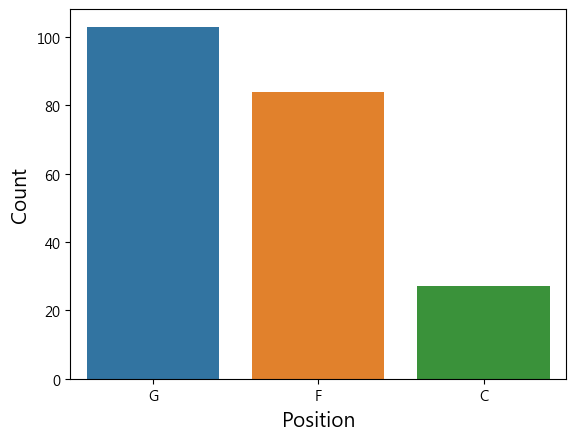

In [32]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

sns.barplot(data=position_counts, x='Position', y='Count', hue='Position')
plt.ylabel('Count', fontsize=14)
plt.xlabel('Position', fontsize=14)

## Class

Text(0, 0.5, 'Position')

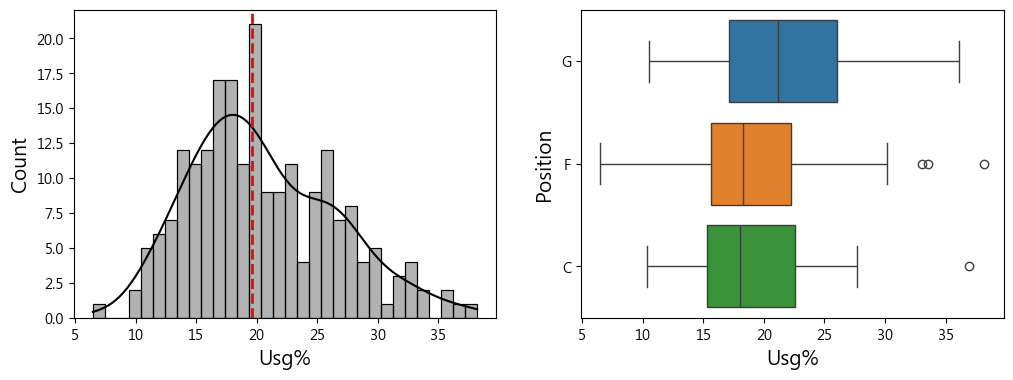

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()
median_Usg = df['Usage_Percentage'].median()
sns.histplot(df['Usage_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].axvline(median_Usg, color='red', linestyle='--', linewidth=2)
ax[0].set_xlabel("Usg%", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)

sns.boxplot(data=df, x='Usage_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("Usg%", fontsize=14)
ax[1].set_ylabel("Position", fontsize=14)

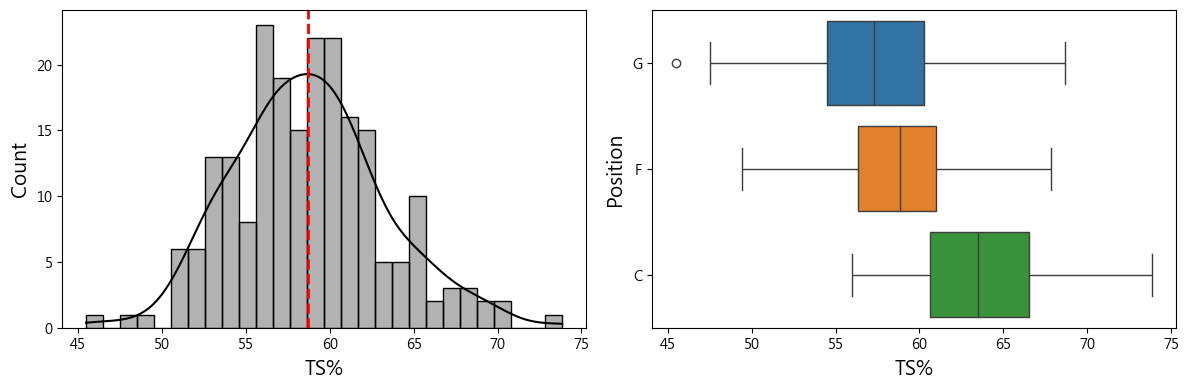

In [34]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']
mean_TS = df['True_Shooting_Percentage'].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

sns.histplot(df['True_Shooting_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].axvline(mean_TS, color='red', linestyle='--', linewidth=2)
ax[0].set_xlabel("TS%", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)

sns.boxplot(data=df, x='True_Shooting_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("TS%", fontsize=14)
ax[1].set_ylabel("Position", fontsize=14)

plt.tight_layout()
plt.show()

In [35]:
variable_df = df[['Age', 'Player_Name', 'Position', 'Points_Per_Game', 'Field_Goal_Percentage', 'Offensive_Rebounds_Per_Game', 'Defensive_Rebounds_Per_Game', 'Blocks_Per_Game' , 'Fouls_Per_Game',
                  'True_Shooting_Percentage', 'Effective_Field_Goal_Percentage', 'Usage_Percentage', 'Turnovers_Percentage', 'Assists_Percentage',
                  'Three_Point_Percentage', 'Two_Point_Percentage', 'Free_Throw_Percentage', 'Salary']]
variable_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Percentage':'FGg',
                             'Free_Throw_Percentage':'FT%','Three_Point_Percentage':'3P%', 'Two_Point_Percentage':'2P%', 'Usage_Percentage':"USG%", 'Fouls_Per_Game':'FSg',
                             'True_Shooting_Percentage':'TS%', 'Turnovers_Percentage':'TOV%', 'Assists_Percentage':'AST%', 'Defensive_Rebounds_Per_Game':'DRg', 'Blocks_Per_Game':'BKg',
                             'Effective_Field_Goal_Percentage':'eFG%', 'Offensive_Rebounds_Per_Game':'ORg'}, inplace=True)

C:\Users\No\AppData\Local\Temp\ipykernel_19364\550249183.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variable_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Percentage':'FGg',


In [36]:
variable_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          214 non-null    int64  
 1   Player_Name  214 non-null    object 
 2   Position     214 non-null    object 
 3   PPg          214 non-null    float64
 4   FGg          214 non-null    float64
 5   ORg          214 non-null    float64
 6   DRg          214 non-null    float64
 7   BKg          214 non-null    float64
 8   FSg          214 non-null    float64
 9   TS%          214 non-null    float64
 10  eFG%         214 non-null    float64
 11  USG%         214 non-null    float64
 12  TOV%         214 non-null    float64
 13  AST%         214 non-null    float64
 14  3P%          214 non-null    float64
 15  2P%          214 non-null    float64
 16  FT%          214 non-null    float64
 17  Salary       214 non-null    float64
dtypes: float64(15), int64(1), object(2)
memory usage: 

In [37]:
class_variable_df = variable_df.copy()

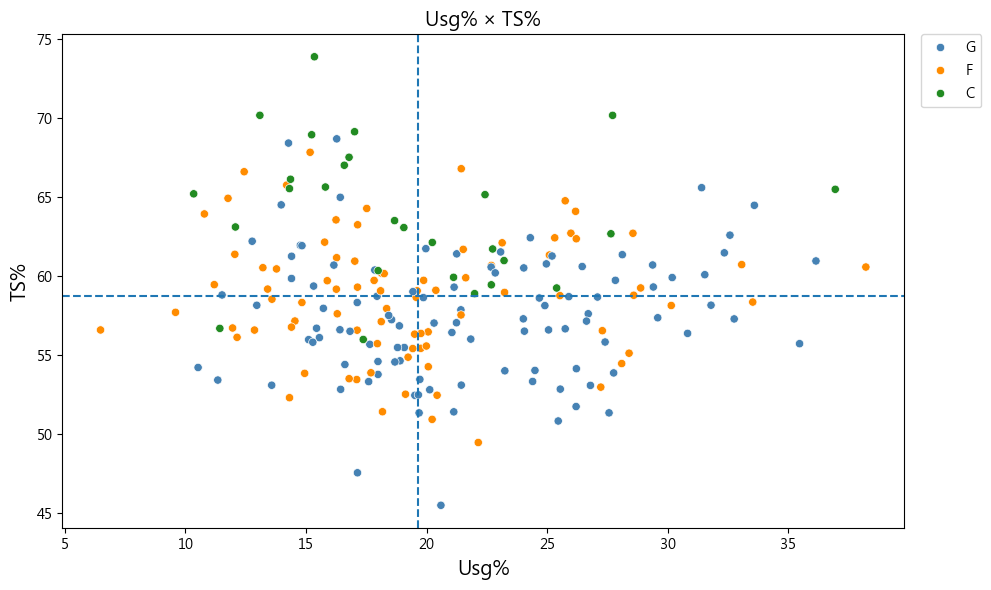

In [38]:
USG_median = class_variable_df['USG%'].median()
TS_mean = class_variable_df['TS%'].mean()

class_variable_df['USG_class'] = np.where(class_variable_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_variable_df['TS_class'] = np.where(class_variable_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_variable_df['Quadrant'] = (class_variable_df['USG_class']+' & '+class_variable_df['TS_class'])

colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=class_variable_df, x='USG%', y='TS%', hue='Position', hue_order=['G', 'F', 'C'], palette=colors)
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usg%', fontsize=14)
ax.set_ylabel('TS%', fontsize=14)
ax.set_title('Usg% × TS%', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

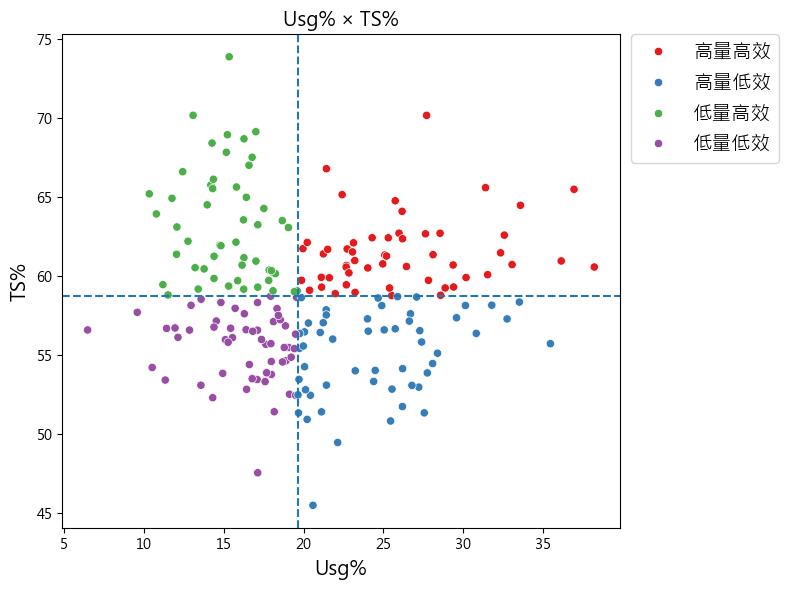

In [39]:
USG_median = class_variable_df['USG%'].median()
TS_mean = class_variable_df['TS%'].mean()

class_variable_df['USG_class'] = np.where(class_variable_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_variable_df['TS_class'] = np.where(class_variable_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_variable_df['Quadrant'] = (class_variable_df['USG_class']+' & '+class_variable_df['TS_class'])
class_variable_df['Quadrant'] = class_variable_df['Quadrant'].replace({'High_USG & High_TS':'高量高效', 'High_USG & Low_TS':'高量低效',
                                                                       'Low_USG & High_TS':'低量高效', 'Low_USG & Low_TS':'低量低效'})
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=class_variable_df, x='USG%', y='TS%', hue='Quadrant', palette='Set1')
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usg%', fontsize=14)
ax.set_ylabel('TS%', fontsize=14)
ax.set_title('Usg% × TS%', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0, fontsize=14)
plt.tight_layout()
plt.show()

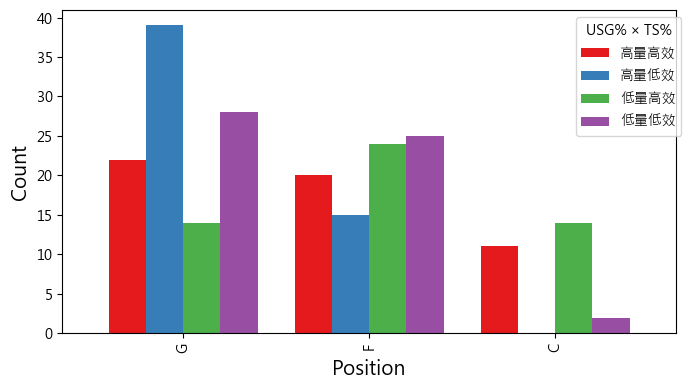

In [40]:
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'] 
table = pd.crosstab(class_variable_df['Position'], 
                    class_variable_df['Quadrant']).reindex(['G','F','C'])

table[['高量高效','高量低效',
       '低量高效','低量低效']].plot(kind='bar', figsize=(7,4), width=0.8, color=colors)

plt.ylabel('Count', fontsize=14)
plt.xlabel('Position', fontsize=14)
plt.legend(title='USG% × TS%', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

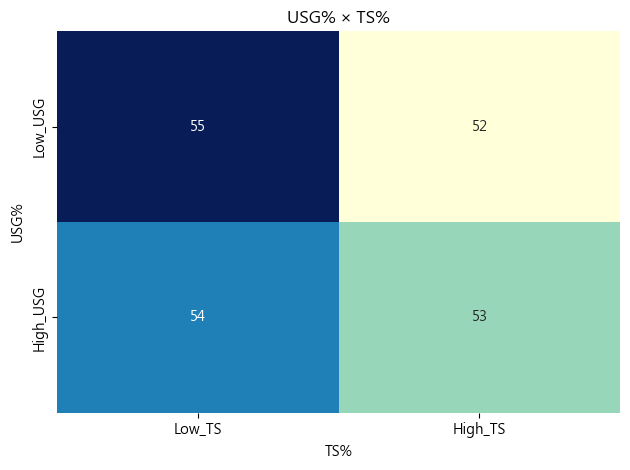

In [41]:
table_2x2 = pd.crosstab(class_variable_df['USG_class'],
                        class_variable_df['TS_class'],margins=False).reindex(index=['Low_USG', 'High_USG'], 
                                                                              columns=['Low_TS', 'High_TS'])

sns.heatmap(table_2x2, annot=True, cmap='YlGnBu', fmt='g', cbar=False)

plt.xlabel('TS%')
plt.ylabel('USG%')
plt.title('USG% × TS%')
plt.tight_layout()
plt.show()


In [42]:
class_variable_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          214 non-null    int64  
 1   Player_Name  214 non-null    object 
 2   Position     214 non-null    object 
 3   PPg          214 non-null    float64
 4   FGg          214 non-null    float64
 5   ORg          214 non-null    float64
 6   DRg          214 non-null    float64
 7   BKg          214 non-null    float64
 8   FSg          214 non-null    float64
 9   TS%          214 non-null    float64
 10  eFG%         214 non-null    float64
 11  USG%         214 non-null    float64
 12  TOV%         214 non-null    float64
 13  AST%         214 non-null    float64
 14  3P%          214 non-null    float64
 15  2P%          214 non-null    float64
 16  FT%          214 non-null    float64
 17  Salary       214 non-null    float64
 18  USG_class    214 non-null    object 
 19  TS_class

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

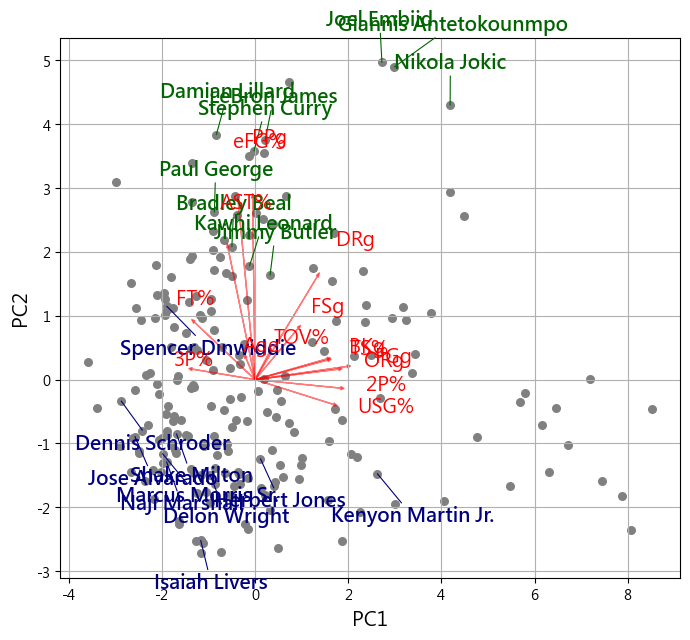

In [44]:
features = ['Age', 'PPg', 'FGg', 'ORg', 'DRg', 'BKg', 'FSg',  'TS%',  'USG%','eFG%','TOV%', 'AST%', '3P%', '2P%', 'FT%']

scaler = StandardScaler()
X_ = scaler.fit_transform(variable_df.drop(columns=['Player_Name', 'Position', 'Salary']))
X_scaled = StandardScaler().fit_transform(X_)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

X_df = df.loc[variable_df.index].copy()
X_df['PC1'] = pca_result[:, 0]
X_df['PC2'] = pca_result[:, 1]
top10_idx = X_df.nlargest(10, 'Salary').index
bottom10_idx = X_df.nsmallest(10, 'Salary').index

plt.figure(figsize=(7, 6.5))
plt.scatter(X_df['PC1'], X_df['PC2'],color='gray', s=30)

for idx in top10_idx:
    row = X_df.loc[idx]
    x, y = row['PC1'], row['PC2']
    name = row['Player_Name']
    plt.annotate(text=name, xy=(x, y), xytext=(x-1.2, y+0.5),
                 color='darkgreen', fontsize=14, fontweight='bold', ha='left', va='bottom',
                 arrowprops={'arrowstyle': '-', 'color': 'darkgreen', 'linewidth': 0.8, 'shrinkA': 0, 'shrinkB': 0})

for idx in bottom10_idx:
    row = X_df.loc[idx]
    x, y = row['PC1'], row['PC2']
    name = row['Player_Name']
    plt.annotate(text=name, xy=(x, y), xytext=(x-1, y-0.5),
                 color='navy', fontsize=14, fontweight='bold', ha='left', va='top',
                 arrowprops={'arrowstyle': '-', 'color': 'navy', 'linewidth': 0.8, 'shrinkA': 0, 'shrinkB': 0})

scaling_factor = 5
loading = pca.components_.T

for i, var in enumerate(features):
    plt.arrow(0, 0,loading[i, 0] * scaling_factor, loading[i, 1] * scaling_factor, 
              color='r', alpha=0.5, head_width=0.05)
    plt.text(loading[i, 0]* 5*1.3, loading[i, 1]*5*1.3, 
             var, color='r', fontsize=14)

    
plt.xlabel("PC1", fontsize=14)
plt.ylabel("PC2", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

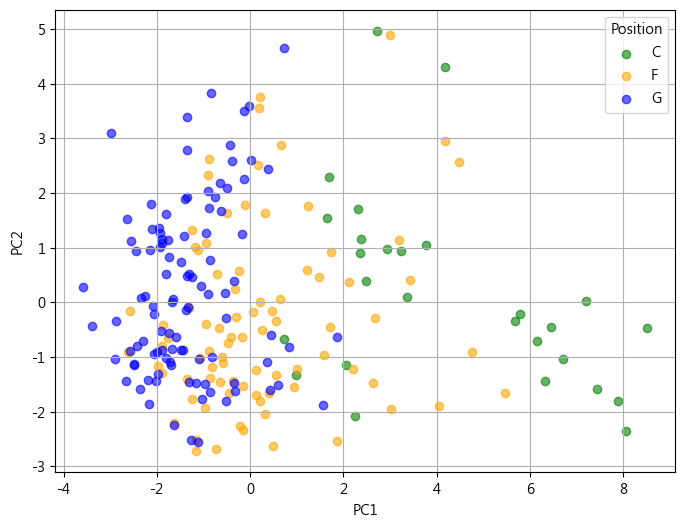

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for pos, color in [('C', 'green'), ('F', 'orange'), ('G', 'blue')]:
    subset = X_df[X_df['Position'] == pos]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        alpha=0.6, label=pos, color=color
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Position")
plt.grid(True)
plt.show()


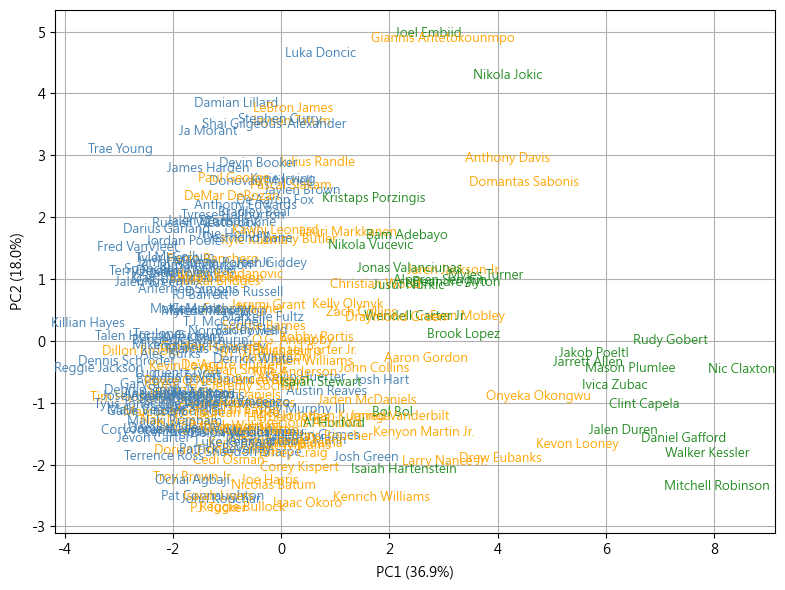

In [46]:
plt.figure(figsize=(8, 6))

colors = {'C':'forestgreen', 'F':'orange', 'G':'steelblue'}
for pos, col in colors.items():
    sub = X_df[X_df['Position'] == pos]
    plt.scatter(sub['PC1'], sub['PC2'], label=pos, color=col, alpha=0)

for idx, row in X_df.iterrows():
    x = row['PC1']
    y = row['PC2']
    name = row['Player_Name']
    pos  = row['Position']
    plt.text(x, y, name, color=colors[pos], 
             fontsize=9, ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()


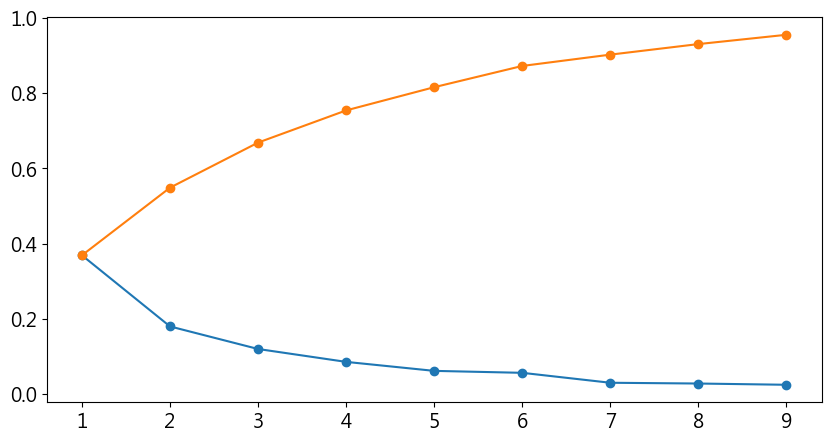

,0,1,2,3,4,5,6,7,8
explained_variance,0.368647,0.179701,0.119754,0.085524,0.061650,0.056455,0.030054,0.028032,0.024705
cum_explained_variance,0.368647,0.548349,0.668103,0.753627,0.815277,0.871733,0.901787,0.929819,0.954524


In [47]:
scaler = StandardScaler()
per_df_scaled = scaler.fit_transform(variable_df.drop(columns=['Player_Name', 'Position', 'Salary']))
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(per_df_scaled)
# pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='explined variance')
plt.plot(range(1, len(cum_explained_variance)+1), cum_explained_variance, marker='o', label='cumulative explained variance')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

eigenvalues = pd.DataFrame({'explained_variance':explained_variance, 'cum_explained_variance':cum_explained_variance})
eigenvalues.T

In [48]:
PC_df = pd.DataFrame(x_pca, 
                     columns=[f'PC{i+1}' for i in range(x_pca.shape[1])],
                     index=variable_df.index)
PC_df['Player_Name'] = variable_df['Player_Name']
PC_df['Position'] = variable_df['Position']
PC_df['Salary'] = variable_df['Salary']
PC_df['Total_Points'] = df['Total_Points']

In [49]:
num_cols = variable_df.drop(columns=['Player_Name', 'Position', 'Salary']).columns

rotation_matrix = pca.components_.T  

top3_rotation = rotation_matrix[:, :3]

top3_df = pd.DataFrame(top3_rotation, columns=['PC1', 'PC2', 'PC3'], index=num_cols)
def highlight_max(s):
    is_max = abs(s) == abs(s).max()
    return ['font-weight: bold; color: red' if v else '' for v in is_max]

top3_df.T.round(2).style.apply(highlight_max, axis=0).format("{:.2f}")


,Age,PPg,FGg,ORg,DRg,BKg,FSg,TS%,eFG%,USG%,TOV%,AST%,3P%,2P%,FT%
PC1,-0.04,-0.01,0.40,0.36,0.27,0.31,0.18,0.31,0.34,-0.07,0.06,-0.12,-0.27,0.37,-0.26
PC2,0.07,0.57,0.04,0.03,0.32,0.07,0.16,0.06,-0.08,0.56,0.09,0.41,0.03,-0.03,0.18
PC3,0.26,0.12,0.12,-0.21,-0.12,-0.09,-0.37,0.45,0.39,0.02,-0.34,-0.05,0.32,0.20,0.30


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 263 (\N{LATIN SMALL LETTER C WITH ACUTE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


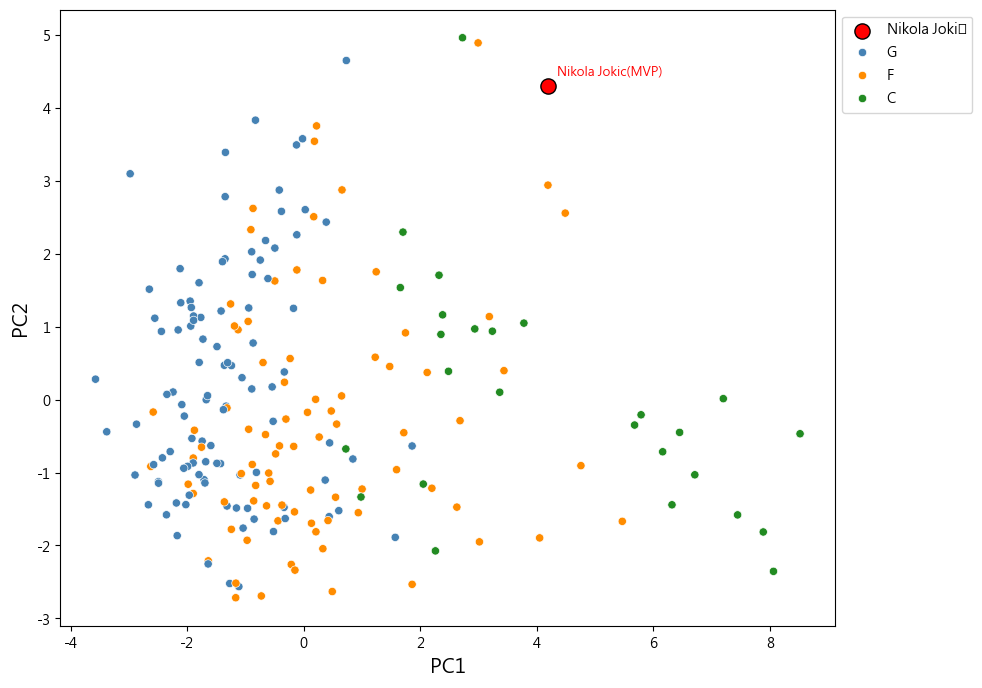

In [50]:
positions = ['G', 'F', 'C']
colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}

jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_variable_df['Position'], hue_order=positions, palette=colors)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 263 (\N{LATIN SMALL LETTER C WITH ACUTE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


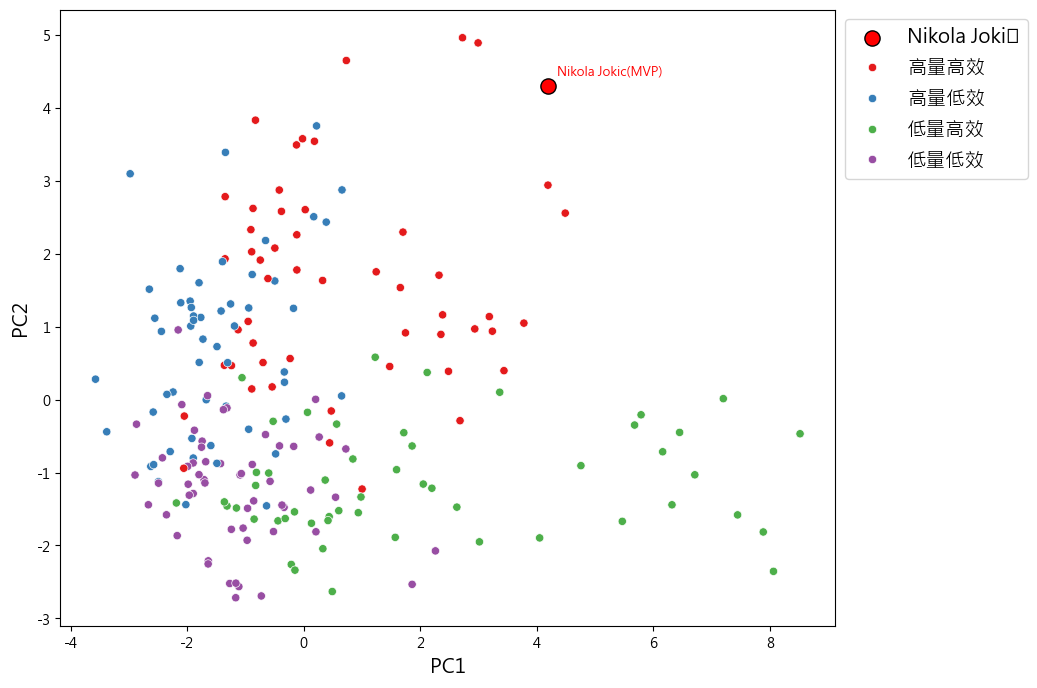

In [51]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_variable_df['Quadrant'], 
                     palette=['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'] )
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
plt.show()

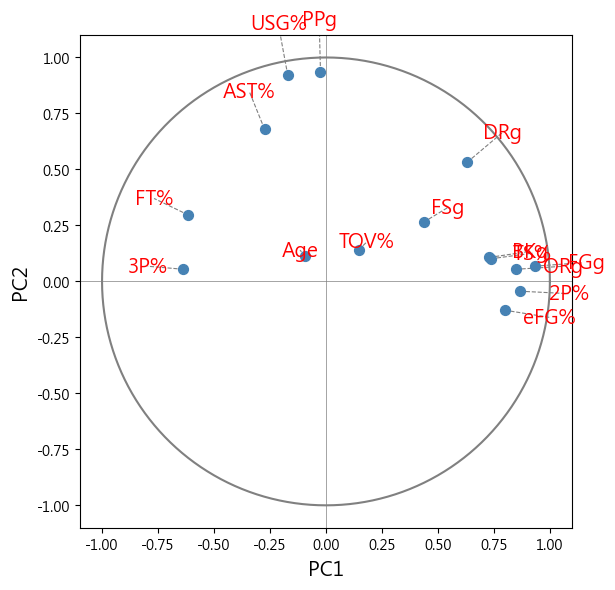

In [52]:
num_cols = variable_df.drop(columns=['Player_Name', 'Position', 'Salary']).columns
X_std = StandardScaler().fit_transform(variable_df[num_cols])

n, p = X_std.shape

cov_mat = np.cov(X_std.T, bias=False)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)

idx_sorted = np.argsort(eigen_val)[::-1]
lamda_ = eigen_val[idx_sorted][:2]
vector_ = eigen_vec[:, idx_sorted][:, :2]

corr = vector_ * np.sqrt(lamda_) 

theta = np.linspace(0, 2*np.pi, 361)
ucircle = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ucircle[:,0], ucircle[:,1], color='grey')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

for i, col in enumerate(num_cols):
    x, y = corr[i, 0], corr[i, 1]

    ax.scatter(x, y, color='steelblue', s=50, zorder=3)
    x_text, y_text = x * 1.25, y * 1.25

    ax.plot([x, x_text], [y, y_text], color='gray', linestyle='--', linewidth=0.8)

    ax.text(x_text, y_text, col, fontsize=14, color='red',
            ha='center', va='center')

ax.set_xlabel(f'PC1', fontsize=14)
ax.set_ylabel(f'PC2', fontsize=14)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()


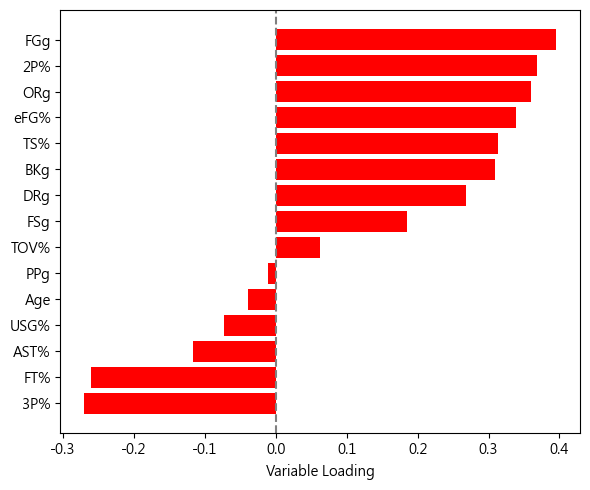

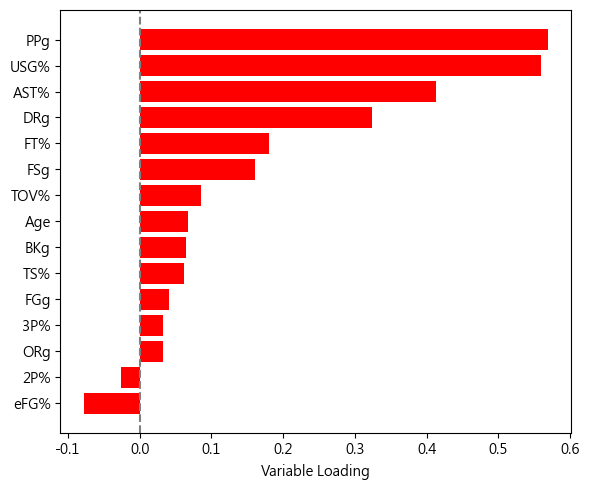

In [53]:
loading_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=num_cols  
)

def plot_loading_dotchart(component_name, color='red'):
    loading = loading_df[component_name].sort_values()
    plt.figure(figsize=(6, 5))
    plt.barh(loading.index, loading.values, color=color)
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel('Variable Loading')
    plt.tight_layout()
    plt.show()

for pc in ['PC1', 'PC2']:
    plot_loading_dotchart(pc)


In [54]:
top_players = class_variable_df.nlargest(10, 'Salary')
top_player_coords = x_pca[class_variable_df.index.isin(top_players.index)]
top_player_names = top_players['Player_Name'].values

bottom_players = class_variable_df.nsmallest(10, 'Salary')
bottom_player_coords = x_pca[class_variable_df.index.isin(bottom_players.index)]
bottom_player_names = bottom_players['Player_Name'].values


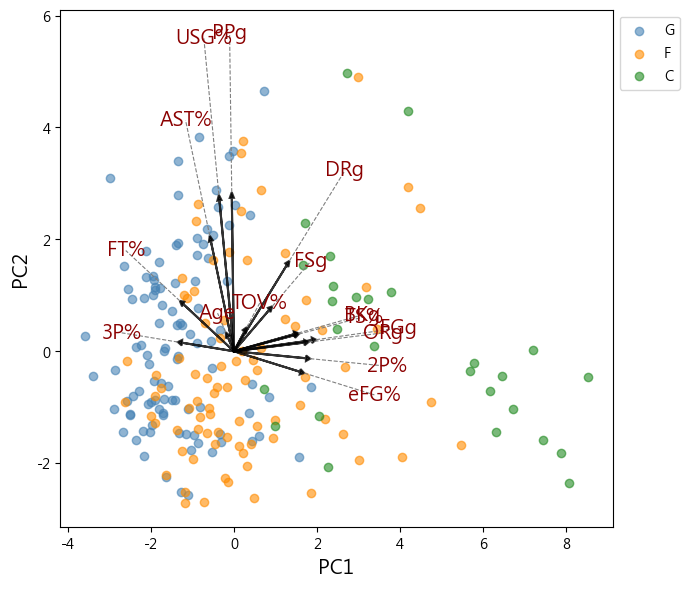

In [55]:
positions = ['G', 'F', 'C']
colors = {'G': 'steelblue', 'F': 'darkorange', 'C': 'forestgreen'}

fig, ax = plt.subplots(figsize=(7, 6))

scaling_factor = 5
loading = pca.components_.T[:, :2]
x_pca_scaled = x_pca[:, :2]

position_labels = class_variable_df['Position'].values

for pos in positions:
    idx = position_labels == pos
    ax.scatter(x_pca_scaled[idx, 0], x_pca_scaled[idx, 1], alpha=0.6, color=colors[pos], label=pos)

for i, var in enumerate(num_cols):
    x, y = loading[i, 0] * scaling_factor, loading[i, 1] * scaling_factor
    ax.arrow(0, 0, x, y, color='black', alpha=0.8,
             head_width=0.1, head_length=0.1, linewidth=1.5, length_includes_head=True)
    x_text = x * 2
    y_text = y * 2
    ax.plot([x, x_text], [y, y_text], linestyle='--', color='gray', linewidth=0.8)
    ax.text(x_text, y_text, var, fontsize=14, color='darkred',
            ha='center', va='center')


ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


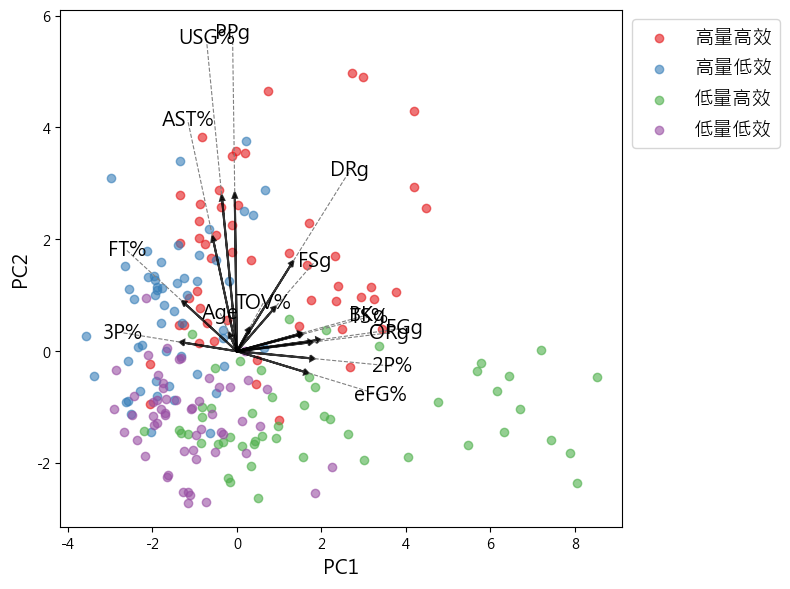

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

scaling_factor = 5
loading = pca.components_.T[:, :2]
x_pca_scaled = x_pca[:, :2]

quadrants = ['高量高效','高量低效', '低量高效','低量低效']
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
color_map = dict(zip(quadrants, palette))

quadrant_labels = class_variable_df['Quadrant'].values

for quad in quadrants:
    idx = quadrant_labels == quad
    ax.scatter(
        x_pca_scaled[idx, 0], x_pca_scaled[idx, 1],
        alpha=0.6,
        color=color_map[quad],
        label=quad
    )

# for i, var in enumerate(num_cols):
#     ax.arrow(0, 0,
#              loading[i, 0] * scaling_factor,
#              loading[i, 1] * scaling_factor,
#              color='k', alpha=0.6, head_width=0.05)
#     ax.text(loading[i, 0] * scaling_factor * 1.3,
#             loading[i, 1] * scaling_factor * 1.3,
#             var, color='k', fontsize=14)
    
for i, var in enumerate(num_cols):
    x, y = loading[i, 0] * scaling_factor, loading[i, 1] * scaling_factor
    ax.arrow(0, 0, x, y, color='black', alpha=0.8,
             head_width=0.1, head_length=0.1, linewidth=1.5, length_includes_head=True)
    x_text = x * 2
    y_text = y * 2
    ax.plot([x, x_text], [y, y_text], linestyle='--', color='gray', linewidth=0.8)
    ax.text(x_text, y_text, var, fontsize=14, color='k',
            ha='center', va='center')
    
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)

ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)

plt.tight_layout()
plt.show()

In [57]:
features = ['Age', 'PPg', 'FGg', 'ORg', 'DRg', 'BKg', 'FSg',  'TS%',  'USG%','eFG%','TOV%', 'AST%', '3P%', '2P%', 'FT%']

melted_df = class_variable_df[['Quadrant']+['Position']+features].melt(id_vars=['Quadrant', 'Position'], var_name='Variable', value_name='Value')

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop

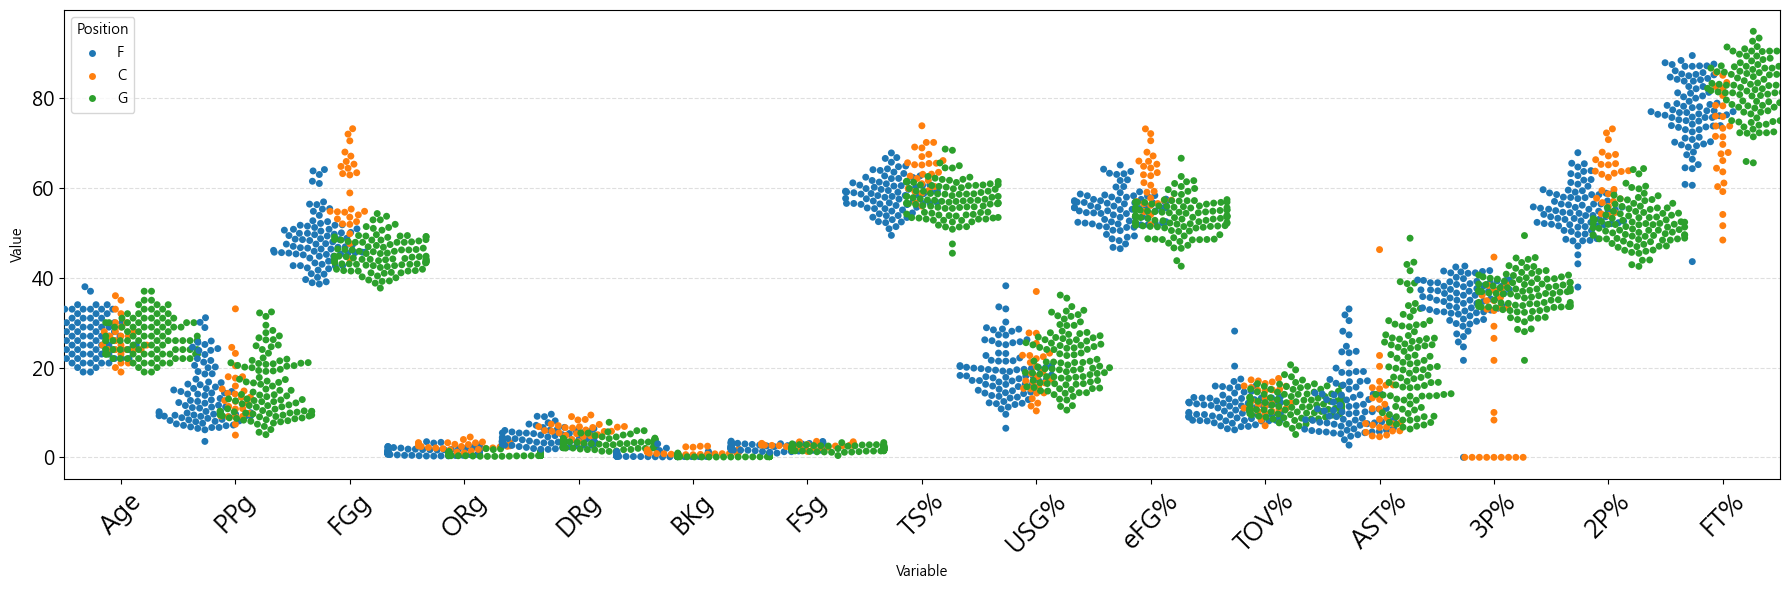

In [58]:
plt.figure(figsize=(18, 6))
sns.swarmplot(data=melted_df, x='Variable', y='Value', hue='Position', dodge=True)
plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 56.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\No\anaconda3\envs\Lapto

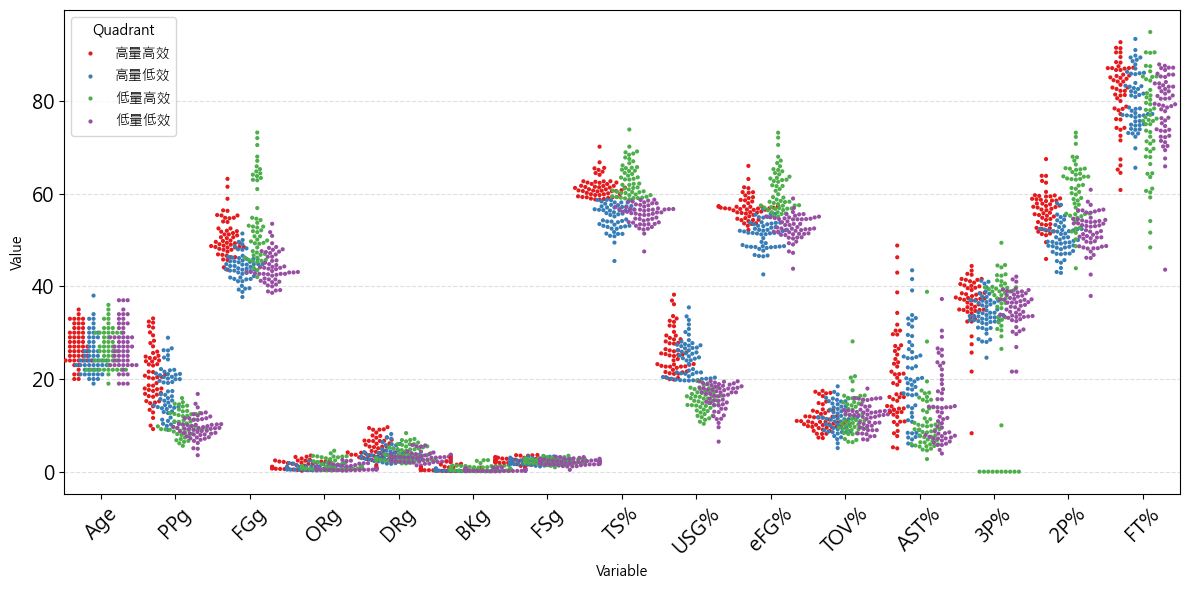

In [59]:
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
plt.figure(figsize=(12, 6))
sns.swarmplot(data=melted_df, x='Variable', y='Value', hue='Quadrant', 
              dodge=True, palette=palette, size=3)

plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


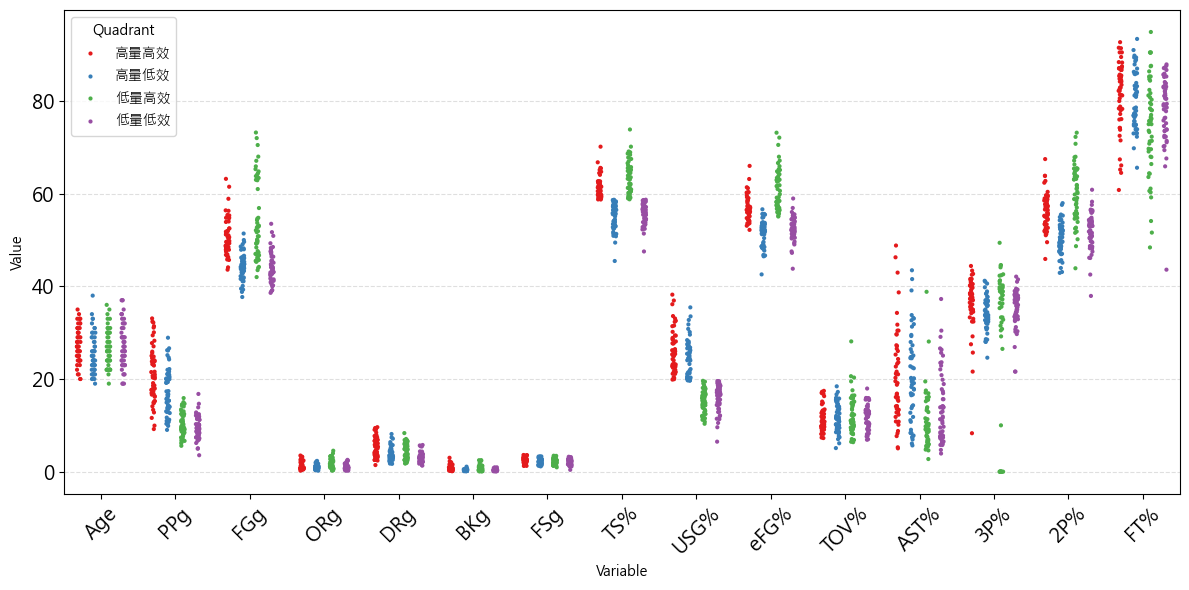

In [60]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=melted_df, x='Variable', y='Value', hue='Quadrant', 
              dodge=True, palette=palette, size=3)

plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


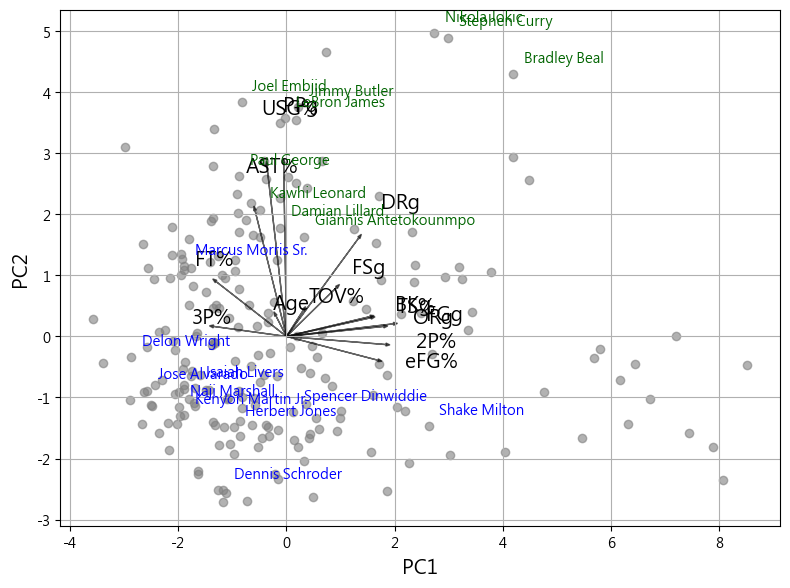

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

scaling_factor = 5
loading = pca.components_.T[:, :2]
x_pca_scaled = x_pca[:, :2]

for quad in quadrants:
    idx = quadrant_labels == quad
    ax.scatter(
        x_pca_scaled[idx, 0], x_pca_scaled[idx, 1],
        alpha=0.6,
        color='gray',
        label=quad
    )

for i, var in enumerate(num_cols):
    ax.arrow(0, 0,
             loading[i, 0] * scaling_factor,
             loading[i, 1] * scaling_factor,
             color='k', alpha=0.6, head_width=0.05)
    ax.text(loading[i, 0] * scaling_factor * 1.3,
            loading[i, 1] * scaling_factor * 1.3,
            var, color='k', fontsize=14)
for i, name in enumerate(top_player_names):
    x, y = top_player_coords[i, 0], top_player_coords[i, 1]
    ax.text(x + 0.2, y + 0.2, name, fontsize=10, color='darkgreen', zorder=20)

for i, name in enumerate(bottom_player_names):
    x, y = bottom_player_coords[i, 0], bottom_player_coords[i, 1]
    ax.text(x + 0.2, y + 0.2, name, fontsize=10, color='blue', zorder=20)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
PC_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Player_Name,Position,Salary,Total_Points
0,0.181591,3.545124,0.534106,-1.371755,-0.055574,-0.182622,0.121336,-0.530795,-0.624279,Jayson Tatum,F,32600060.0,2225
1,2.723767,4.965524,0.576686,-1.007224,1.073131,0.966804,0.485015,0.631600,-0.445464,Joel Embiid,C,53320232.0,2183
2,0.729186,4.652884,0.038577,-0.316206,-1.004304,-0.602363,-1.361283,-0.101981,0.019888,Luka Doncic,G,43031940.0,2138
3,-0.126469,3.494853,0.583155,-1.251504,-0.583835,1.009575,0.705458,0.899321,0.662280,Shai Gilgeous-Alexander,G,35859950.0,2135
4,2.991424,4.894648,-1.142372,-0.279695,0.386565,-0.982190,-1.562989,-0.461543,0.172080,Giannis Antetokounmpo,F,45640084.0,1959
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,-0.319916,-1.630390,-0.637668,2.484984,0.146569,1.357927,0.421227,0.457472,-0.299431,Alex Caruso,G,9245000.0,374
210,-0.966138,-1.490269,1.060355,1.364318,0.125193,-0.914393,0.950729,0.097941,-0.663899,Delon Wright,G,947205.0,369
211,-1.116045,-2.564270,-0.205549,-0.230090,0.442242,-0.692194,0.175248,-0.258976,-0.624010,John Konchar,G,2250000.0,364
212,-1.166682,-2.517191,0.242829,-0.922749,0.025548,0.573080,0.336019,0.179011,-0.122964,Isaiah Livers,F,1563518.0,346


In [63]:
top30_df = PC_df.nlargest(30, 'Total_Points').reset_index(drop=True)

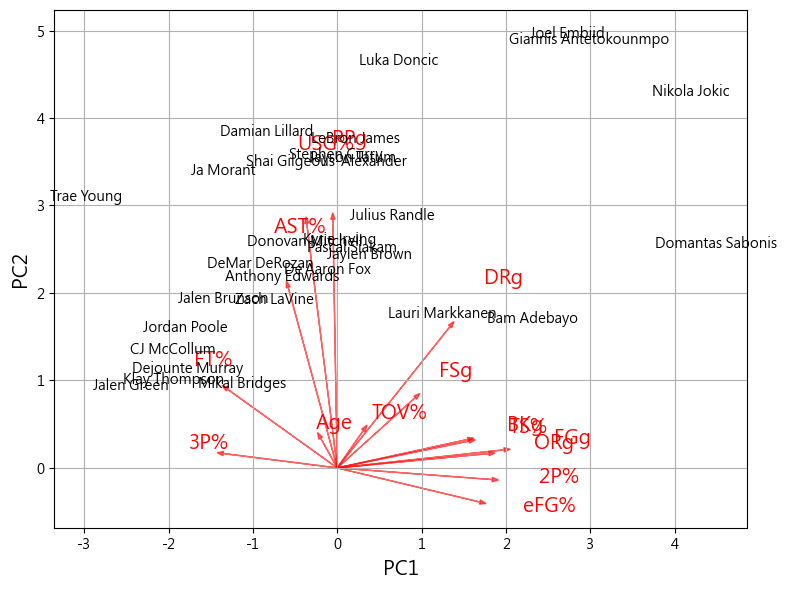

In [64]:
loading = pca.components_.T[:, :2]

plt.figure(figsize=(8, 6))

sns.scatterplot(data=top30_df, x='PC1', y='PC2', s=80, alpha=0)

ax = plt.gca()

for i, var in enumerate(num_cols):
    ax.arrow(0, 0,
             loading[i, 0] * scaling_factor,
             loading[i, 1] * scaling_factor,
             color='r', alpha=0.6, head_width=0.05)
    ax.text(loading[i, 0] * scaling_factor * 1.3,
            loading[i, 1] * scaling_factor * 1.3,
            var, color='r', fontsize=14)
    
for i, row in top30_df.iterrows():
    ax.text(row['PC1'], row['PC2'], row['Player_Name'], fontsize=10, ha='center', va='center')

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.grid(True)
plt.tight_layout()
plt.show()

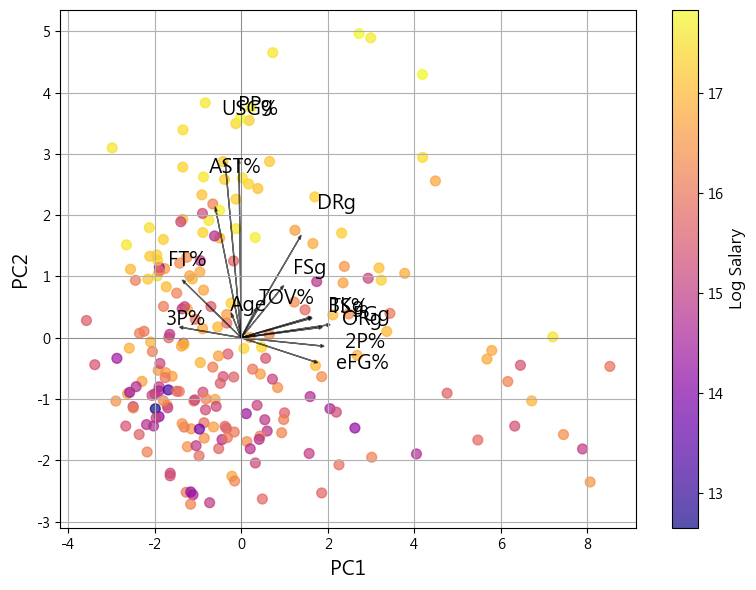

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

scaling_factor = 5
loading = pca.components_.T[:, :2]
x_pca_scaled = x_pca[:, :2]

salary_log = np.log(class_variable_df['Salary'])

scatter = ax.scatter(
    x_pca_scaled[:, 0],
    x_pca_scaled[:, 1],
    c=salary_log,
    cmap='plasma',  
    alpha=0.7,
    s=50
)

for i, var in enumerate(num_cols):
    ax.arrow(0, 0,
             loading[i, 0] * scaling_factor,
             loading[i, 1] * scaling_factor,
             color='k', alpha=0.6, head_width=0.05)
    ax.text(loading[i, 0] * scaling_factor * 1.3,
            loading[i, 1] * scaling_factor * 1.3,
            var, color='k', fontsize=14)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Log Salary', fontsize=12)

plt.tight_layout()
plt.show()


In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
features = ['Age', 'PPg', 'FGg', 'TS%', 'ORg', 'DRg', 'BKg','FSg', 'eFG%', 'USG%', 'TOV%', 'AST%', '3P%', '2P%', 'FT%']

X = variable_df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

loading_matrix = np.array(top3_df.values)

PC_scores = np.dot(X_scaled, loading_matrix)  # shape: (n_samples, 3)
PC_df = pd.DataFrame(PC_scores, columns=['PC1', 'PC2', 'PC3'])

y = np.log(variable_df['Salary'].values)

X_train, X_test, y_train, y_test = train_test_split(PC_df, y, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_log = reg.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)
r2 = r2_score(y_true, y_pred)

print(f"Test R²  : {r2:.2f}")


Test R²  : 0.56


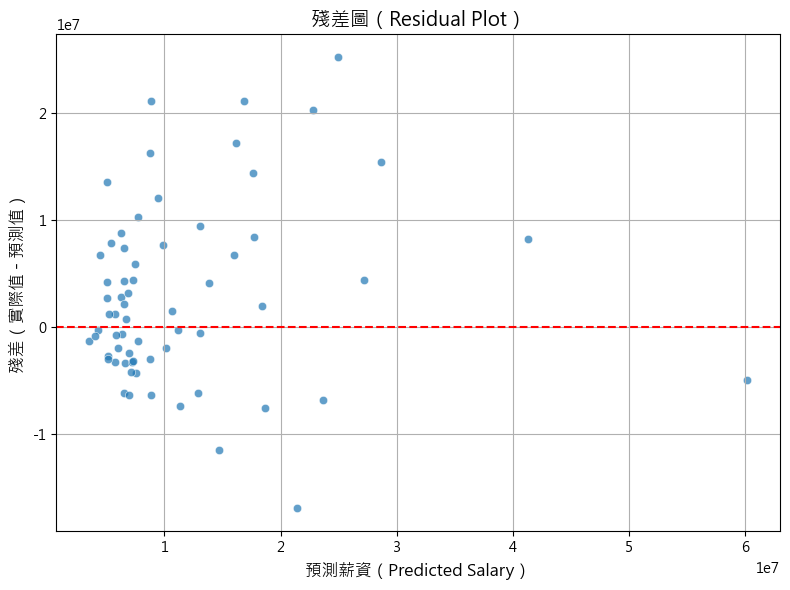

In [67]:
residuals = y_true - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("預測薪資（Predicted Salary）", fontsize=12)
plt.ylabel("殘差（實際值 - 預測值）", fontsize=12)
plt.title("殘差圖（Residual Plot）", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [68]:
rfr = RandomForestRegressor(random_state=42, n_estimators=500)
rfr.fit(X_train, y_train)

y_pred_log2 = rfr.predict(X_test)
y_pred2 = np.exp(y_pred_log2)
y_true2 = np.exp(y_test)
r22 = r2_score(y_true2, y_pred2)
print(f"Test R²  : {r22:.2f}")


Test R²  : 0.44


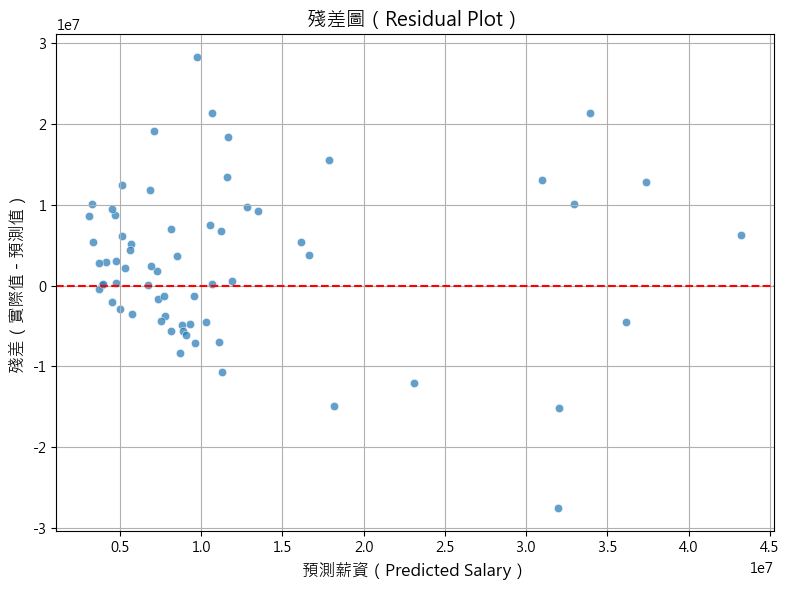

In [69]:
residuals2 = y_true2 - y_pred2

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred2, y=residuals2, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("預測薪資（Predicted Salary）", fontsize=12)
plt.ylabel("殘差（實際值 - 預測值）", fontsize=12)
plt.title("殘差圖（Residual Plot）", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


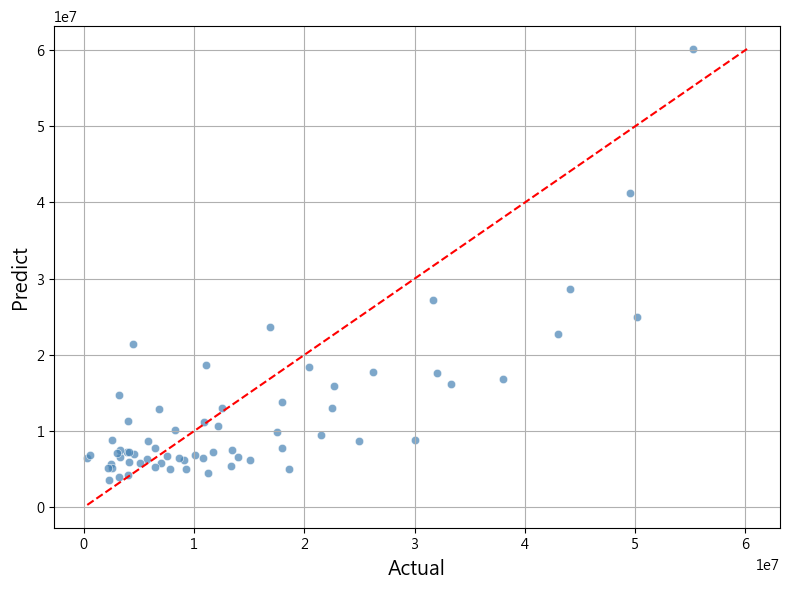

In [70]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, color='steelblue')

max_val = max(np.max(y_true), np.max(y_pred))
min_val = min(np.min(y_true), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel("Actual", fontsize=14)
plt.ylabel("Predict", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

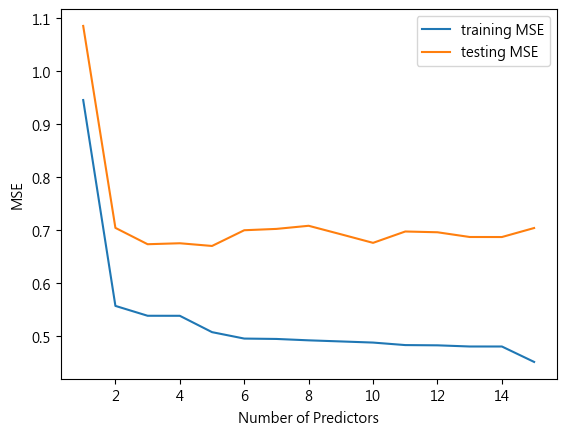

In [108]:
from sklearn.metrics import mean_squared_error
X = variable_df.drop(columns=['Player_Name', 'Position', 'Salary'])
y = np.log(variable_df['Salary'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std =scaler.transform(X_test)

train_errors = []
test_errors = []
n_features = X.shape[1]

for k in range(1, n_features+1):
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)
    lr = LinearRegression()
    model = lr.fit(X_train_pca, y_train)
    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.plot(range(1, n_features+1), train_errors, label='training MSE')
plt.plot(range(1, n_features+1), test_errors, label='testing MSE')
plt.xlabel("Number of Predictors")
plt.ylabel("MSE")
plt.legend()
plt.show()

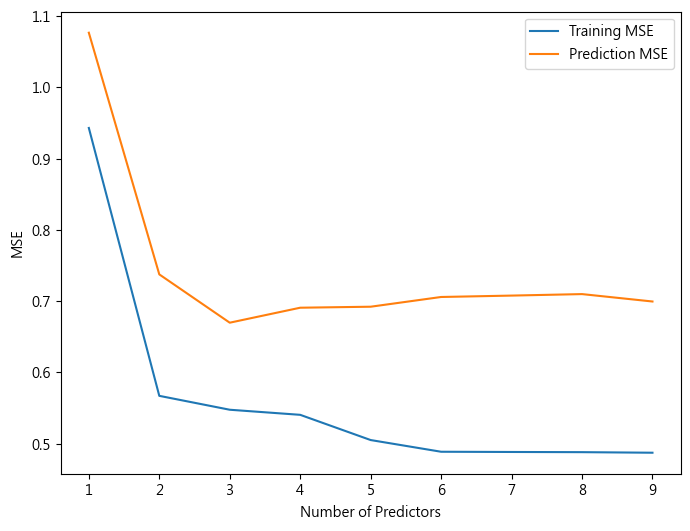

In [110]:
top9_rotation = rotation_matrix[:, :9]

top9_df = pd.DataFrame(top9_rotation, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'], index=num_cols)

X = variable_df[features].values
y = np.log(variable_df['Salary'].values)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

loading_matrix = np.array(top9_df.values)  # 如 topN_df.columns = ['PC1', ..., 'PC15']

train_errors = []
test_errors = []

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

for k in range(1, loading_matrix.shape[1] + 1):
    loading_k = loading_matrix[:, :k]

    PC_train = np.dot(X_train_scaled, loading_k)
    PC_test = np.dot(X_test_scaled, loading_k)

    model = LinearRegression()
    model.fit(PC_train, y_train)

    y_train_pred_log = model.predict(PC_train)
    y_test_pred_log = model.predict(PC_test)

    mse_train = mean_squared_error(y_train, y_train_pred_log)
    mse_test = mean_squared_error(y_test, y_test_pred_log)

    train_errors.append(mse_train)
    test_errors.append(mse_test)
    
plt.figure(figsize=(8, 6))
plt.plot(range(1, loading_matrix.shape[1] + 1), train_errors, label='Training MSE')
plt.plot(range(1, loading_matrix.shape[1] + 1), test_errors, label='Prediction MSE')
plt.xlabel("Number of Predictors")
plt.ylabel("MSE")
plt.legend()
plt.show()
